# Comparação dos resultados

Este notebook descobre todos os cenários em `tests/results`, calcula as métricas por execução e mostra cada gráfico em uma célula independente. Ele reutiliza as funções do fluxo oficial para manter métricas, ordem, nomes e cores sincronizados com `plot_comparison_aggregated.py`.

## Preparação

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D

current_dir = Path.cwd().resolve()
project_root = (
    current_dir.parent.parent
    if current_dir.name == "notebooks" and current_dir.parent.name == "tests"
    else current_dir
)
results_dir = project_root / "tests/results"

if not results_dir.is_dir():
    raise FileNotFoundError("A pasta tests/results não foi encontrada.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from plot_comparison_aggregated import metric_upper_bound, prepare_plot_data
from plot_comparison_common import (
    COMPARISON_METRICS,
    CONFIGURATION_COLORS,
    CONFIGURATION_LABELS,
)
from plot_helper import compute_run_metrics, discover_result_files, summarize_runs

## Métricas por execução

A descoberta não usa uma lista local de cenários. Todo CSV no padrão `<execução>_<ordem>_<cenário>.csv` participa da comparação, incluindo HPA e VPA.

In [2]:
discovered_df = discover_result_files(results_dir, CONFIGURATION_LABELS)
run_df = pd.DataFrame(
    compute_run_metrics(row) for _, row in discovered_df.iterrows()
).sort_values(["order", "run", "configuration"])
summary_df = summarize_runs(run_df, COMPARISON_METRICS)

availability_df = (
    run_df.groupby(["order", "configuration", "label"], as_index=False)
    .size()
    .rename(columns={"size": "execuções"})
)

print(f"Arquivos analisados: {len(run_df)}")
availability_df

Arquivos analisados: 800


,order,configuration,label,execuções
0,0,base_1,Base 1 Repl,50
1,0,base_5,Base 5 Repl,50
2,1,hpa_std,HPA Std,50
3,2,hpa_fast,HPA Fast,50
4,3,csa_h,CSA Python H,50
5,3,csa_hq_25,CSA Python HQ 25,50
6,3,csa_hq_50,CSA Python HQ 50,50
7,3,csa_java_h,CSA Java H,50
8,3,csa_java_hq_25,CSA Java HQ 25,50
9,3,csa_java_hq_50,CSA Java HQ 50,50


## Dados calculados

In [3]:
run_df

,run,order,configuration,label,file,pods_mean,cpu_limits_mean,response_size_mean,response_time_mean,success_rate,slo_breach_success_rate
0,01,0,base_1,Base 1 Repl,/home/rodrigo/Work/pesquisa/custom-self-adapte...,1.000000,0.300000,1.061195e+06,2025.356021,64.356755,74.741596
1,01,0,base_5,Base 5 Repl,/home/rodrigo/Work/pesquisa/custom-self-adapte...,5.000000,0.300000,1.061180e+06,472.480730,100.000000,5.528508
2,02,0,base_1,Base 1 Repl,/home/rodrigo/Work/pesquisa/custom-self-adapte...,1.000000,0.317246,1.061185e+06,2097.162527,52.301665,74.802330
3,02,0,base_5,Base 5 Repl,/home/rodrigo/Work/pesquisa/custom-self-adapte...,5.000000,0.300000,1.061187e+06,484.004065,100.000000,6.096725
4,03,0,base_1,Base 1 Repl,/home/rodrigo/Work/pesquisa/custom-self-adapte...,1.000000,0.300000,1.061195e+06,2086.820974,54.270313,75.913088
...,...,...,...,...,...,...,...,...,...,...,...
795,49,6,csa_vq,CSA Python VQ,/home/rodrigo/Work/pesquisa/custom-self-adapte...,1.163934,0.816098,3.747721e+05,573.085664,80.033070,12.475651
796,50,6,csa_java_v,CSA Java V,/home/rodrigo/Work/pesquisa/custom-self-adapte...,1.000000,0.927869,1.061188e+06,812.782739,20.119520,30.682367
797,50,6,csa_java_vq,CSA Java VQ,/home/rodrigo/Work/pesquisa/custom-self-adapte...,1.114754,0.919279,4.691800e+05,636.929905,80.232907,15.761923
798,50,6,csa_v,CSA Python V,/home/rodrigo/Work/pesquisa/custom-self-adapte...,1.000000,0.935049,1.061196e+06,737.137206,18.265516,20.520569


In [4]:
summary_df

,order,configuration,label,metric,metric_title,runs,mean,min,max,median,std,q25,q75
1,0,base_1,Base 1 Repl,cpu_limits_mean,Média do limite de CPU (fração de CPU),50,0.307632,0.300000,0.323902,0.309656,0.007509,0.300000,0.313590
7,0,base_5,Base 5 Repl,cpu_limits_mean,Média do limite de CPU (fração de CPU),50,0.300000,0.300000,0.300000,0.300000,0.000000,0.300000,0.300000
13,1,hpa_std,HPA Std,cpu_limits_mean,Média do limite de CPU (fração de CPU),50,0.300000,0.300000,0.300000,0.300000,0.000000,0.300000,0.300000
19,2,hpa_fast,HPA Fast,cpu_limits_mean,Média do limite de CPU (fração de CPU),50,0.300000,0.300000,0.300000,0.300000,0.000000,0.300000,0.300000
25,3,csa_h,CSA Python H,cpu_limits_mean,Média do limite de CPU (fração de CPU),50,0.300000,0.300000,0.300000,0.300000,0.000000,0.300000,0.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,5,vpa,VPA,success_rate,Respostas 200 (%),50,84.863546,24.892756,100.000000,97.529725,19.662227,64.457709,100.000000
76,6,csa_java_v,CSA Java V,success_rate,Respostas 200 (%),50,46.712332,5.843583,97.297410,43.547407,33.261184,15.055090,84.006703
82,6,csa_java_vq,CSA Java VQ,success_rate,Respostas 200 (%),50,77.104728,16.828721,88.148071,79.491390,12.486887,76.612210,83.692625
88,6,csa_v,CSA Python V,success_rate,Respostas 200 (%),50,24.210174,2.186840,97.491947,14.863583,22.043731,12.342522,31.953209


## Gráficos separados

A preparação visual fica nesta célula. Cada gráfico é executado em uma das células seguintes e, portanto, aparece em seu próprio bloco de saída.

In [5]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
    },
)

configurations_df, plot_df = prepare_plot_data(run_df)
configuration_order = configurations_df["configuration"].tolist()
configuration_labels = configurations_df["label"].tolist()
fallback_colors = sns.color_palette("Set2", n_colors=len(configurations_df))
configuration_palette = {
    configuration: CONFIGURATION_COLORS.get(configuration, fallback_colors[index])
    for index, configuration in enumerate(configuration_order)
}
mean_df = plot_df.groupby(
    ["metric", "configuration"], as_index=False, observed=False
)["value"].mean()

stat_legend = [
    Line2D([0], [0], color="black", linewidth=1.5, label="Mediana"),
    Line2D(
        [0], [0], color="#2f2f2f", marker="o", markerfacecolor="#2f2f2f",
        linewidth=0, markersize=5, alpha=0.45, label="Execucoes"
    ),
    Line2D(
        [0], [0], color="#111111", marker="D", markerfacecolor="white",
        linewidth=0, markersize=6, label="Media"
    ),
]


def plot_metric(metric, data=plot_df, means=mean_df, summary=summary_df):
    metric_df = data[data["metric"] == metric.key]
    metric_means = means[means["metric"] == metric.key]
    metric_summary = summary[summary["metric"] == metric.key]
    fig, ax = plt.subplots(figsize=(11, 5.33), layout="constrained")

    sns.boxplot(
        data=metric_df, x="configuration", y="value", order=configuration_order,
        hue="configuration", hue_order=configuration_order,
        palette=configuration_palette, dodge=False, width=0.62, whis=(0, 100),
        saturation=0.85, linewidth=1.1, fliersize=3,
        medianprops={"color": "#1f1f1f", "linewidth": 1.6},
        whiskerprops={"color": "#555555", "linewidth": 1.1},
        capprops={"color": "#555555", "linewidth": 1.1},
        boxprops={"edgecolor": "#333333"}, ax=ax,
    )
    sns.stripplot(
        data=metric_df, x="configuration", y="value", order=configuration_order,
        color="#2f2f2f", size=3.2, jitter=0.18, alpha=0.45, ax=ax,
    )
    sns.scatterplot(
        data=metric_means, x="configuration", y="value", marker="D", s=42,
        color="white", edgecolor="#111111", linewidth=0.9, zorder=5,
        legend=False, ax=ax,
    )

    ax.set_ylim(0, metric_upper_bound(metric_summary, metric.percent_axis))
    ax.set_title(metric.title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks(range(len(configuration_order)), configuration_labels)
    ax.tick_params(axis="x", rotation=40)
    for tick_label in ax.get_xticklabels():
        tick_label.set_ha("right")
        tick_label.set_rotation_mode("anchor")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.grid(axis="x", visible=False)

    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    fig.suptitle("Box = Q1-Q3, linha = mediana, pontos = execucoes, losango = media")
    fig.legend(
        handles=stat_legend, loc="lower center", ncols=3,
        bbox_to_anchor=(0.5, -0.01),
    )
    plt.show()

### Média de Pods

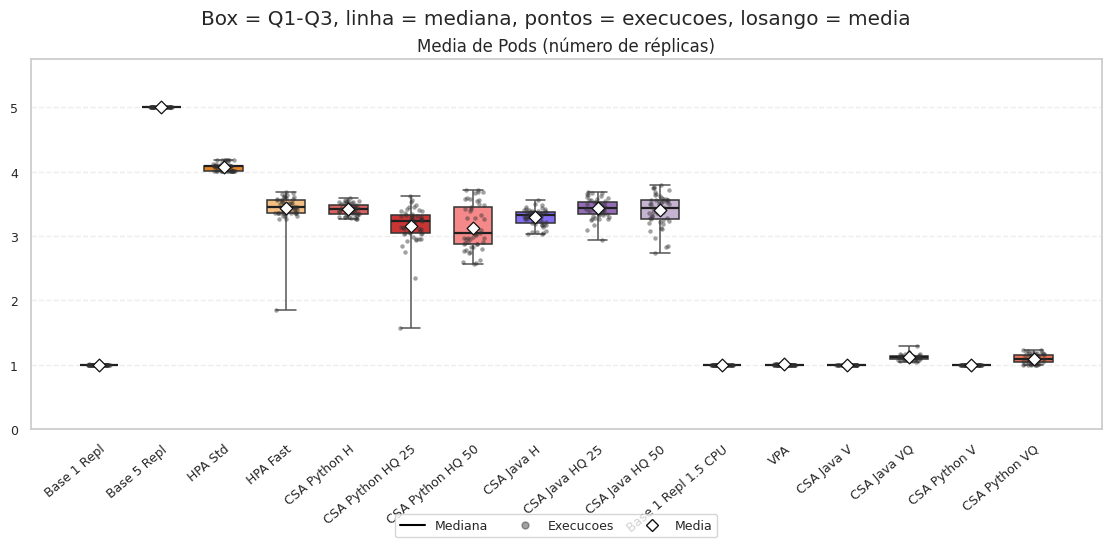

In [6]:
plot_metric(COMPARISON_METRICS[0])

### Limite de CPU

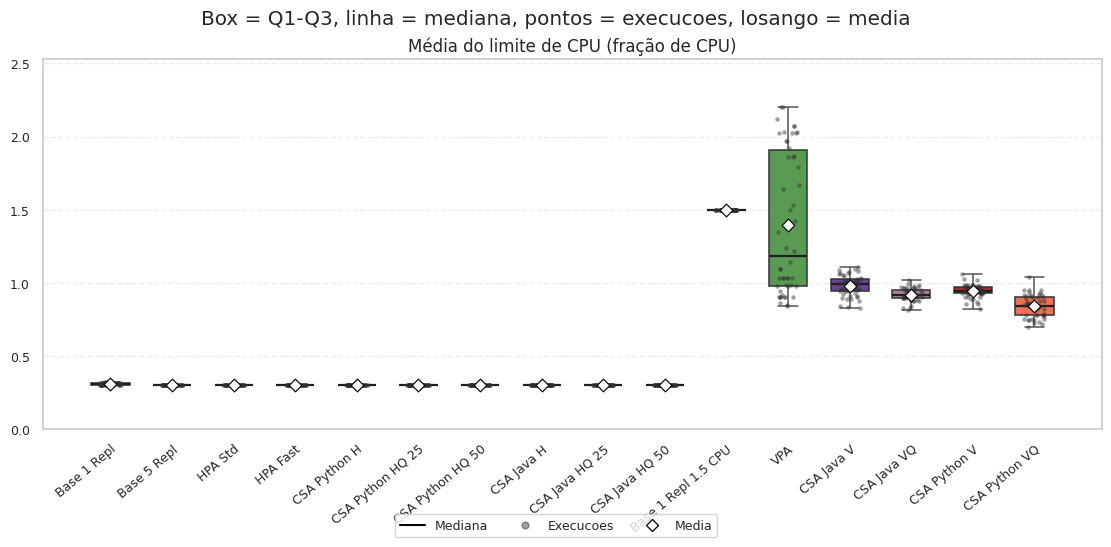

In [7]:
plot_metric(COMPARISON_METRICS[1])

### Tempo médio das respostas

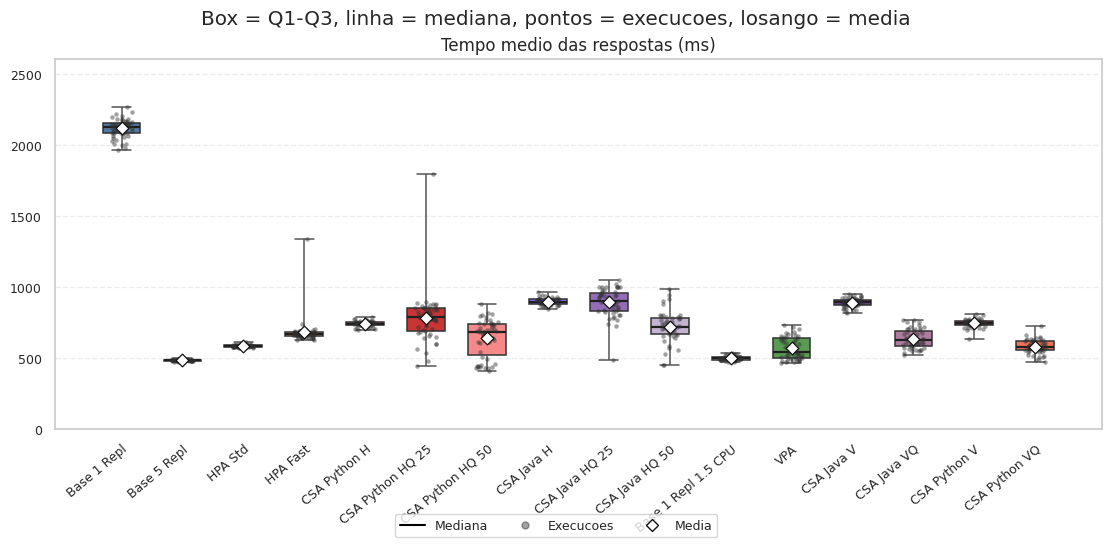

In [8]:
plot_metric(COMPARISON_METRICS[2])

### Tamanho médio das respostas

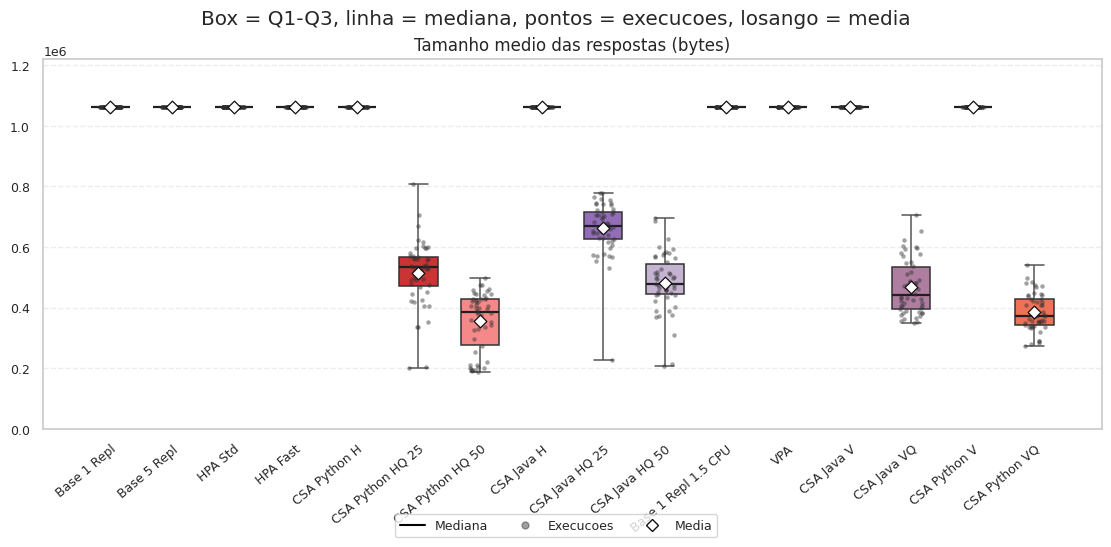

In [9]:
plot_metric(COMPARISON_METRICS[3])

### Respostas 200

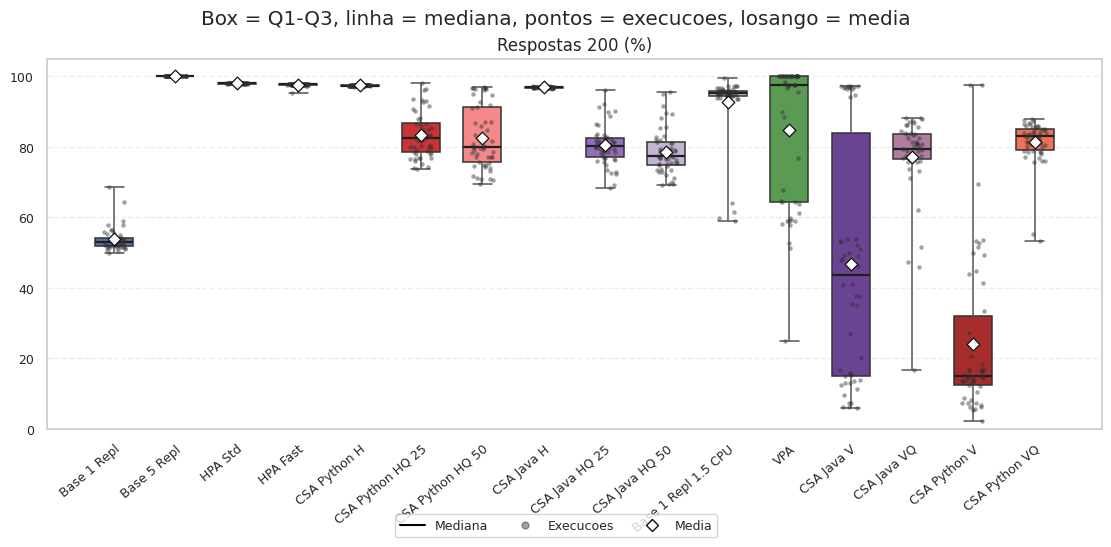

In [10]:
plot_metric(COMPARISON_METRICS[4])

### Requisições acima do SLO

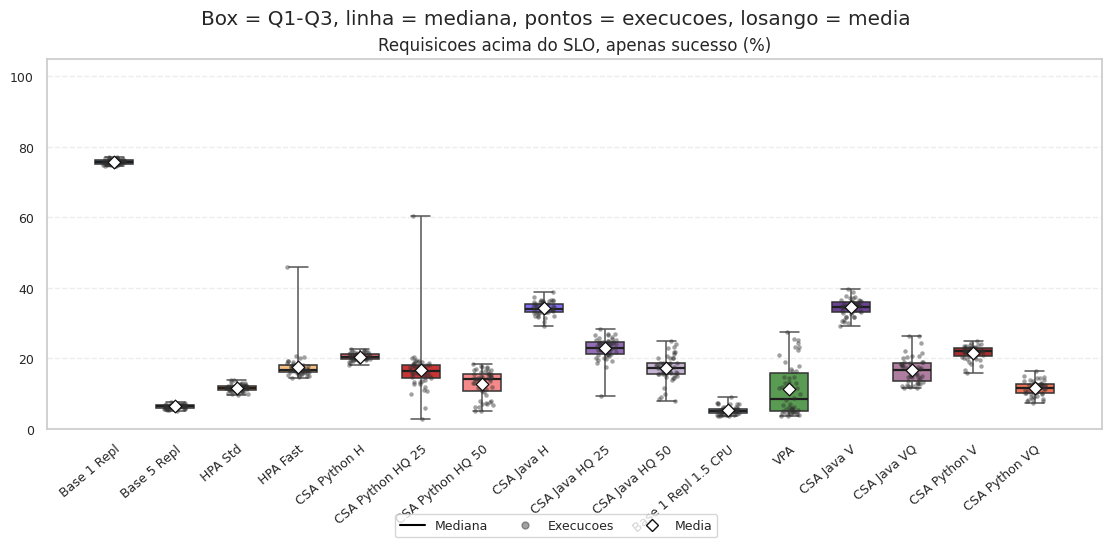

In [11]:
plot_metric(COMPARISON_METRICS[5])

### Violações do SLO por tempo ou status HTTP

O SLO só é atendido quando a resposta é HTTP 200 e o tempo é **menor que 1 segundo**. Tempo maior ou igual a 1 segundo ou status diferente de 200 conta como violação, inclusive erros rápidos. Cada requisição é contada uma única vez.

**Cálculo:** 100 × requisições que violam o SLO / total de requisições. O gráfico anterior permanece com seu cálculo original: tempo maior que 1 segundo, somente entre respostas HTTP 200.


In [12]:
from plot_helper import MetricSpec, apply_standard_renames

slo_violation_metric = MetricSpec(
    "slo_violation_rate",
    "Violações do SLO: tempo ≥ 1 s ou HTTP diferente de 200 (%)",
    percent_axis=True,
)


def slo_violation_rate(requests):
    if requests.empty:
        return float("nan")
    status = pd.to_numeric(requests["loc_status_code"], errors="coerce")
    latency = pd.to_numeric(requests["value"], errors="coerce")
    meets_slo = (status == 200) & (latency < 1000)
    return float((~meets_slo).mean() * 100)


slo_run_rows = []
for _, file_info in discovered_df.iterrows():
    result = apply_standard_renames(pd.read_csv(file_info["file"], low_memory=False))
    requests = result[result["series"] == "loc_response_time"]
    slo_run_rows.append({
        **file_info.to_dict(),
        slo_violation_metric.key: slo_violation_rate(requests),
    })

slo_run_df = pd.DataFrame(slo_run_rows)
slo_summary_df = summarize_runs(slo_run_df, [slo_violation_metric])
slo_plot_df = slo_run_df.melt(
    id_vars=["run", "order", "configuration", "label"],
    value_vars=[slo_violation_metric.key], var_name="metric", value_name="value",
).dropna(subset=["value"])
slo_mean_df = slo_plot_df.groupby(
    ["metric", "configuration"], as_index=False
)["value"].mean()


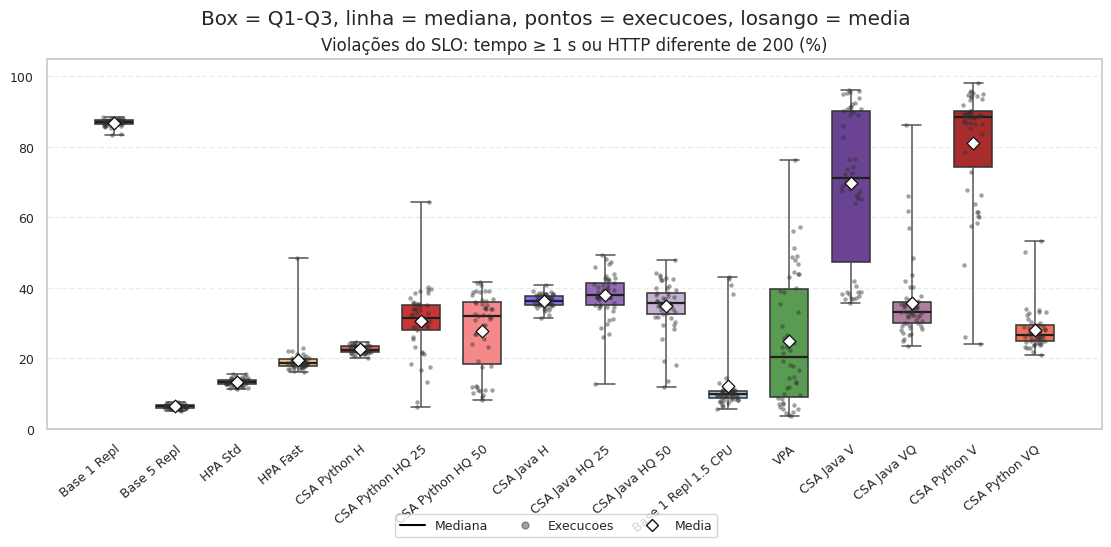

In [13]:
plot_metric(
    slo_violation_metric, data=slo_plot_df, means=slo_mean_df, summary=slo_summary_df
)

### Gráfico de bolhas: recursos, SLO e tamanho das respostas

Cada bolha representa um cenário e usa as médias já calculadas em `summary_df`.

- **Eixo X:** estimativa de provisionamento, calculada como média de pods × média do limite de CPU. Não representa consumo medido.
- **Eixo Y:** requisições acima de 1 segundo, somente entre respostas HTTP 200, seguindo o gráfico de bolhas original.
- **Tamanho da bolha:** tamanho médio das respostas HTTP 200.
- **Contorno destacado:** fronteira de Pareto, minimizando os dois eixos. O tamanho da resposta participa apenas da visualização.

O gráfico também é exportado para `tests/results/compare_bubble_notebook.png`.

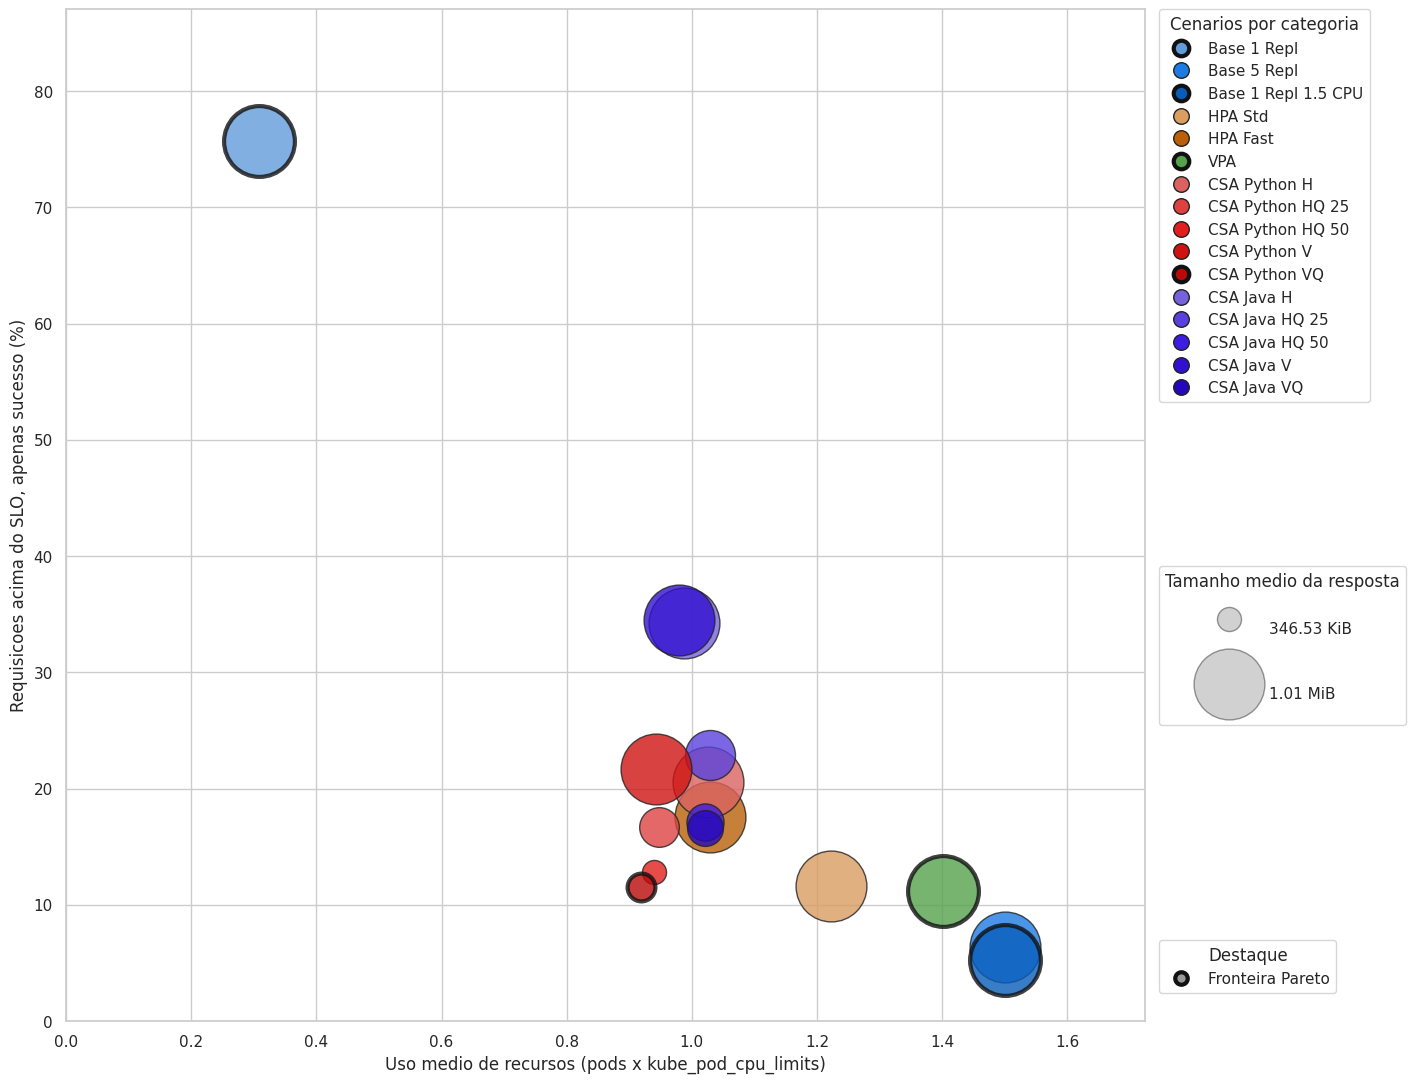

In [14]:
from plot_comparison_bubble import (
    add_pareto_frontier,
    build_plot as build_bubble_plot,
    prepare_plot_data as prepare_bubble_data,
)

bubble_df = add_pareto_frontier(
    prepare_bubble_data(summary_df),
    response_size_objective="ignore",
)
build_bubble_plot(bubble_df, results_dir / "compare_bubble_notebook.png")
plt.show()